# User Features
In this notebook I will create the columns of interesting features per user, that will help me create the groups.

In [1]:
import pandas as pd

In [2]:
users = pd.read_csv('data/preprocessed_data/users_preprocessed.csv')
sessions = pd.read_csv('data/preprocessed_data/sessions_preprocessed.csv')
hotels = pd.read_csv('data/preprocessed_data/hotels_preprocessed.csv')
flights = pd.read_csv('data/preprocessed_data/flights_preprocessed.csv')
invalid_trip_ids = sessions[sessions["cancellation"]]["trip_id"]

# User info

In [3]:
users

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,Age
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07,54
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17,53
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17,45
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24,47
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,2022-03-10,54
...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,2023-04-25,52
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,2023-04-27,47
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,2023-04-30,48
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,2023-05-06,47


In [4]:

def age_group(age):
    if age < 35:
        return "Age Group 18-35"
    elif age <= 50:
        return "Age Group 35-50"
    elif age <= 65:
        return "Age Group 50-65"
    else:
        return "Age Group 65+"

In [5]:
users["Age Group"] = users["Age"].apply(age_group)

In [6]:
user_features = users[["user_id","Age", "gender", "home_country", "home_city","married", "has_children", "Age Group"]].copy() # Feature

<Axes: ylabel='Frequency'>

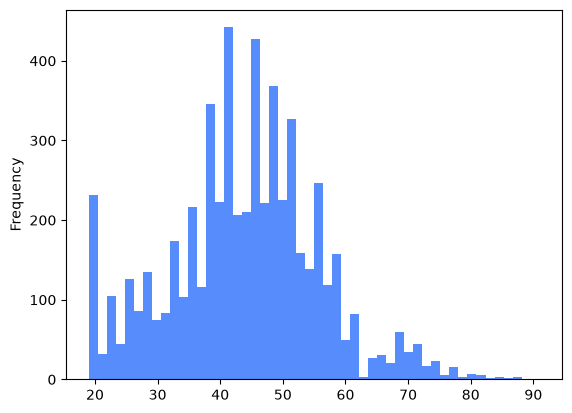

In [7]:
users["Age"].plot(kind="hist", bins=50)

In [8]:
users["Age"].describe()

count    5782.000000
mean       43.881183
std        12.037977
min        19.000000
25%        37.000000
50%        44.000000
75%        51.000000
max        91.000000
Name: Age, dtype: float64

In [9]:
users["Age"].value_counts()

Age
41    233
45    228
50    225
40    223
47    221
     ... 
87      3
86      2
83      2
82      2
91      1
Name: count, Length: 69, dtype: int64

# Sessions trip rate

In [10]:
sessions["user_id"]

0        676570
1        676707
2        682247
3        684521
4        684764
          ...  
48678    646455
48679    656708
48680    659161
48681    662750
48682    668172
Name: user_id, Length: 48683, dtype: int64

In [68]:
sessions_dummy =  sessions[:100][sessions["user_id"] == 217114].copy()

/tmp/ipykernel_17133/1740053753.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sessions_dummy =  sessions[:100][sessions["user_id"] == 217114].copy()


In [69]:
sessions_dummy

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10,217114-e1b93f0863364f1b82932872ac9c28a4,217114,NaN,2023-03-28 20:12:00,2023-03-28 20:12:45,0.05,0.1,False,False,6,False


In [50]:
sessions_dummy.sort_values("session_start", inplace=True)

In [51]:
sessions_dummy

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10,217114-e1b93f0863364f1b82932872ac9c28a4,217114,NaN,2023-03-28 20:12:00,2023-03-28 20:12:45,0.05,0.1,False,False,6,False


In [52]:
sessions_dummy["trip_id"] = sessions_dummy["trip_id"].bfill()

In [53]:
sessions_dummy

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10,217114-e1b93f0863364f1b82932872ac9c28a4,217114,NaN,2023-03-28 20:12:00,2023-03-28 20:12:45,0.05,0.1,False,False,6,False


### working on the cancellations

In [54]:
sessions_dummy

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10,217114-e1b93f0863364f1b82932872ac9c28a4,217114,NaN,2023-03-28 20:12:00,2023-03-28 20:12:45,0.05,0.1,False,False,6,False


In [55]:
invalid_id = sessions_dummy[sessions_dummy["cancellation"]]["trip_id"]

In [56]:
sessions_dummy_valid = sessions_dummy[~sessions_dummy["trip_id"].isin(invalid_id)]

In [57]:
sessions_dummy_valid

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
10,217114-e1b93f0863364f1b82932872ac9c28a4,217114,NaN,2023-03-28 20:12:00,2023-03-28 20:12:45,0.05,0.1,False,False,6,False


In [58]:
sessions_dummy_valid.groupby("trip_id")["trip_id"].count().mean()

nan

In [11]:
def session_trip_rate(sessions_dummy):
    sessions_dummy.sort_values("session_start", inplace=True)
    sessions_dummy["trip_id"] = sessions_dummy["trip_id"].bfill()
    invalid_id = sessions_dummy[sessions_dummy["cancellation"]]["trip_id"]
    sessions_dummy_valid = sessions_dummy[~sessions_dummy["trip_id"].isin(invalid_id)]
    return sessions_dummy_valid.groupby("trip_id")["trip_id"].count().mean()


In [12]:
sesssion_trip_rate_feature = sessions.groupby("user_id").apply(session_trip_rate)  #  Feature

In [19]:
sesssion_trip_rate_feature.name = "trip_session_ratio"

In [21]:
sesssion_trip_rate_feature

user_id
94883     3.666667
101486    3.333333
101961    1.714286
106907    1.500000
118043    2.200000
            ...   
792549    2.000000
796032    3.000000
801660    2.666667
811077    8.000000
844489         NaN
Name: trip_session_ratio, Length: 5782, dtype: float64

# Nights

In [23]:
hotels = pd.read_csv('data/preprocessed_data/hotels_preprocessed.csv')

In [24]:
hotels_w_users = hotels.merge(sessions[["trip_id", "user_id"]], on="trip_id", how="left")

In [25]:
invalid_trip_ids = sessions[sessions["cancellation"]]["trip_id"]

In [26]:
valid_hotels_w_users = hotels_w_users[~hotels_w_users["trip_id"].isin(invalid_trip_ids)]

<Axes: ylabel='Frequency'>

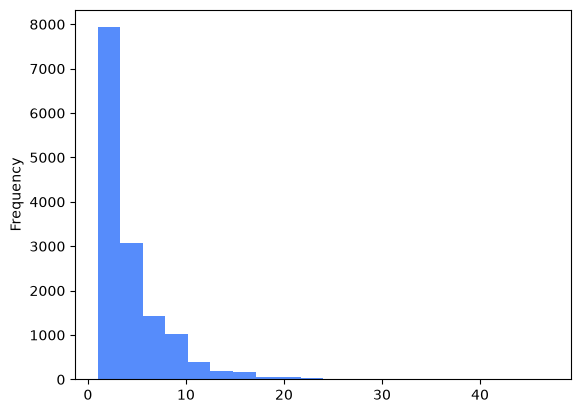

In [27]:
hotels["nights"].plot(kind="hist", bins=20)

## Nights median

In [28]:
nights_median_feature = valid_hotels_w_users.groupby("user_id")["nights"].median() # Feature

In [29]:
nights_median_feature.name = "nights_median"

In [79]:
hotels.duplicated().sum()

np.int64(0)

In [80]:
sessions[sessions["trip_id"] == "106907-718c9cf6c29245fa9b2b31893833ac2c"]

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
5489,106907-92db03fd9d5d44d0944650f51676b869,106907,106907-718c9cf6c29245fa9b2b31893833ac2c,2023-06-06 09:41:00,2023-06-06 09:43:48,NaN,NaN,True,True,23,False
8709,106907-e81b73b444b64b92ab236dabfd06b930,106907,106907-718c9cf6c29245fa9b2b31893833ac2c,2023-07-27 09:43:48,2023-07-27 11:05:14.320529,NaN,NaN,True,True,81,True


we discovered that the checkins are syntetic (or wrong) as we have info for cancelled trips.

## Amount charged nights

In [81]:
valid_hotels_w_users.columns

Index(['trip_id', 'hotel_name', 'nights', 'rooms', 'check_in_time',
       'check_out_time', 'hotel_per_room_usd', 'checkin_weekday',
       'checkout_weekday', 'user_id'],
      dtype='str')

In [30]:
hotels_valid_w_discount = valid_hotels_w_users.merge(sessions[["trip_id", "hotel_discount_amount"]], on="trip_id", how="left")
hotels_valid_w_discount["hotel_discount_amount"] = hotels_valid_w_discount["hotel_discount_amount"].fillna(0)
hotels_valid_w_discount["charged_fare"] = hotels_valid_w_discount["hotel_per_room_usd"]*hotels_valid_w_discount["rooms"]*hotels_valid_w_discount["nights"]*(1-hotels_valid_w_discount["hotel_discount_amount"])

In [83]:
hotels_valid_w_discount[hotels_valid_w_discount["hotel_discount_amount"]>0]

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,checkin_weekday,checkout_weekday,user_id,hotel_discount_amount,charged_fare
22,512201-d198cb30dbe945a58808812558288792,Shangri-La - new york,9,1,2023-01-14 18:09:21.555,2023-01-23 11:00:00,171,Saturday,Monday,512201,0.10,1385.10
23,512628-857fed4132c64aa188ae3c28245f8dc6,Hilton - new york,10,1,2023-01-19 11:00:00.000,2023-01-29 11:00:00,199,Thursday,Sunday,512628,0.10,1791.00
37,524849-fc24ab10f6414ed6a4e0b6915611a80e,Crowne Plaza - new york,12,2,2023-01-24 11:00:00.000,2023-02-05 11:00:00,82,Tuesday,Sunday,524849,0.10,1771.20
39,522607-a1c478eb7e1543df801f670df2ec48b3,Conrad - austin,4,1,2023-01-19 11:12:58.545,2023-01-23 11:00:00,322,Thursday,Monday,522607,0.15,1094.80
64,515578-1cbab2e0499147ce8984d607c316953a,Conrad - vancouver,7,1,2023-02-11 11:00:00.000,2023-02-18 11:00:00,166,Saturday,Saturday,515578,0.15,987.70
...,...,...,...,...,...,...,...,...,...,...,...,...
13899,515580-03ab71f49ddc43f191e378ffd7f50c6f,Shangri-La - winnipeg,11,2,2023-06-22 11:00:00.000,2023-07-03 11:00:00,226,Thursday,Monday,515580,0.10,4474.80
13901,480690-d3d7e67d14d84c919f7401f188bf76b0,Radisson - los angeles,2,1,2023-07-02 20:42:22.545,2023-07-04 11:00:00,194,Sunday,Tuesday,480690,0.05,368.60
13911,518722-adf76389769341c39d235175a92ef961,Starwood - new york,4,1,2023-07-01 16:28:41.655,2023-07-05 11:00:00,73,Saturday,Wednesday,518722,0.05,277.40
13939,578947-db07f13f80c8421f9d2515597e4ff06e,Accor - toronto,14,1,2023-07-14 11:00:00.000,2023-07-28 11:00:00,202,Friday,Friday,578947,0.20,2262.40


In [31]:
hotels_sum_cost = hotels_valid_w_discount.groupby("user_id")["charged_fare"].sum() # Feature
hotels_sum_cost.name = "hotel_tot_rev"
hotels_avg_cost = hotels_valid_w_discount.groupby("user_id")["charged_fare"].mean() # Feature
hotels_avg_cost.name = "hotel_avg_rev"

## Amount hotel bookings

In [33]:
amount_hotel_bookings_feature = hotels_valid_w_discount[["trip_id", "user_id"]].groupby("user_id")["trip_id"].count()  # Features
amount_hotel_bookings_feature.name = "hotels_no_bookings"

## Nights stayed

In [34]:
total_nights_spent_feature = hotels_valid_w_discount.groupby("user_id")["nights"].sum()  # Feature
total_nights_spent_feature.name = "hotel_tot_nights"
average_nights_spent_feature = hotels_valid_w_discount.groupby("user_id")["nights"].mean()  # Feature
average_nights_spent_feature.name = "hotel_avg_nights"

# Flights

In [35]:
flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,522970-fa769adaa4364173a9a24f33b39ee1cf,ATL,vancouver,YVR,1,True,2023-03-15 11:00:00,2023-03-26 11:00:00,0,Korean Air,49.195,-123.182,613.07
1,536782-dd6a5a0600b04528ab9f94c73d6ef7a7,YQG,baltimore,BWI,1,True,2023-03-15 07:00:00,2023-03-18 07:00:00,1,AirTran Airways,39.175,-76.668,109.57
2,589259-b2f1378741d74d82a14a05f1a95106a1,LAX,new york,JFK,1,True,2023-03-14 08:00:00,2023-03-17 08:00:00,2,JetBlue Airways,40.640,-73.779,736.89
3,581577-26647a0bc1b642d6b5c9e5d4824f86de,PWM,edmonton,YXD,1,True,2023-03-15 10:00:00,2023-03-17 10:00:00,1,Delta Air Lines,53.667,-113.467,566.71
4,570625-840957fb34484d71bee7e6564fef0cc8,LGA,oklahoma city,TIK,3,True,2023-03-20 09:00:00,2023-03-22 09:00:00,0,American Airlines,35.393,-97.601,1114.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13762,624198-c5c7b4c8f5774191bc2ebb0d796c39e3,JFK,toronto,YTZ,1,True,2023-03-11 07:00:00,2023-03-22 07:00:00,1,Porter Airlines,43.862,-79.370,115.33
13763,572479-fb6a78a33b054425ba90a5319391fa2a,PWM,jacksonville,NCA,1,True,2023-03-12 16:00:00,2023-03-19 16:00:00,1,Ryanair,30.494,-81.688,285.30
13764,608287-6c767f7877af429eb60ca4c4491e4c92,DAL,montreal,YUL,1,True,2023-03-11 16:00:00,2023-03-13 16:00:00,1,Allegiant Air,45.517,-73.417,424.48
13765,635303-997e40b6c47e4bdf9ca4a81b15928afe,LAX,louisville,LOU,2,True,2023-03-12 07:00:00,2023-03-13 07:00:00,1,Ryanair,38.228,-85.664,905.34


In [37]:
flights_w_users = flights.merge(sessions[["trip_id", "user_id"]], on="trip_id", how="left")

In [38]:
flights_valid = flights_w_users[~flights_w_users["trip_id"].isin(invalid_trip_ids)]

## Amount flights

In [39]:
amount_flights_feature = flights_valid[["trip_id", "seats", "user_id"]].groupby("user_id")["trip_id"].count()  # Features
amount_flights_feature.name = "flight_no_bookings"


In [40]:
amount_flights_feature

user_id
94883     3
101486    2
101961    6
106907    1
118043    3
         ..
785186    2
792549    4
796032    2
801660    3
811077    1
Name: flight_no_bookings, Length: 4891, dtype: int64

In [41]:
flights_valid[flights_valid["user_id"] == 101961]

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id
3095,101961-29a8ff7c9910469c959fffa60215cf78,BOS,montreal,YHU,1,True,2023-02-08 07:00:00,2023-02-13 07:00:00,1,United Airlines,45.517,-73.417,77.02,101961
3415,101961-c4c922fbc83342779565d249ee5e6bf7,BOS,charlotte,CLT,1,True,2023-06-27 11:00:00,2023-07-05 11:00:00,0,JetBlue Airways,35.214,-80.943,216.57,101961
4515,101961-f92e8fdfcdb14e188f296cce3a092e5b,BOS,hamilton,HLZ,1,True,2023-03-04 07:00:00,2023-03-06 07:00:00,0,Air New Zealand,43.173,-79.935,129.90,101961
5069,101961-19f641633ebc442799662326f0b4dfa0,BOS,new york,LGA,1,True,2023-05-05 11:00:00,2023-05-09 11:00:00,0,Allegiant Air,40.640,-73.779,49.67,101961
7590,101961-836fd88487d240baa4402c8e4c6f188c,BOS,seattle,BFI,1,True,2023-03-16 07:00:00,2023-03-21 07:00:00,1,Kenmore Air,47.530,-122.302,769.50,101961
10515,101961-8ad7b7cd7fb246f8b2e28d6d85a7bbed,BOS,los angeles,LSQ,1,True,2022-03-03 15:00:00,2022-03-05 15:00:00,1,American Airlines,33.942,-118.408,686.54,101961


## Average Seats

In [42]:
seats_average_feature = flights_valid[["trip_id", "seats", "user_id"]].groupby("user_id")["seats"].mean() # Feature
seats_average_feature.name = "flight_avg_seats"

In [43]:
flights_valid_w_discount = flights_valid.merge(sessions[["trip_id", "flight_discount_amount"]], on="trip_id", how="left")

In [44]:
flights_valid_w_discount["flight_discount_amount"] = flights_valid_w_discount["flight_discount_amount"].fillna(0)

In [45]:
flights_valid_w_discount

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id,flight_discount_amount
0,522970-fa769adaa4364173a9a24f33b39ee1cf,ATL,vancouver,YVR,1,True,2023-03-15 11:00:00,2023-03-26 11:00:00,0,Korean Air,49.195,-123.182,613.07,522970,0.0
1,536782-dd6a5a0600b04528ab9f94c73d6ef7a7,YQG,baltimore,BWI,1,True,2023-03-15 07:00:00,2023-03-18 07:00:00,1,AirTran Airways,39.175,-76.668,109.57,536782,0.0
2,589259-b2f1378741d74d82a14a05f1a95106a1,LAX,new york,JFK,1,True,2023-03-14 08:00:00,2023-03-17 08:00:00,2,JetBlue Airways,40.640,-73.779,736.89,589259,0.0
3,581577-26647a0bc1b642d6b5c9e5d4824f86de,PWM,edmonton,YXD,1,True,2023-03-15 10:00:00,2023-03-17 10:00:00,1,Delta Air Lines,53.667,-113.467,566.71,581577,0.0
4,570625-840957fb34484d71bee7e6564fef0cc8,LGA,oklahoma city,TIK,3,True,2023-03-20 09:00:00,2023-03-22 09:00:00,0,American Airlines,35.393,-97.601,1114.50,570625,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13197,624198-c5c7b4c8f5774191bc2ebb0d796c39e3,JFK,toronto,YTZ,1,True,2023-03-11 07:00:00,2023-03-22 07:00:00,1,Porter Airlines,43.862,-79.370,115.33,624198,0.0
13198,572479-fb6a78a33b054425ba90a5319391fa2a,PWM,jacksonville,NCA,1,True,2023-03-12 16:00:00,2023-03-19 16:00:00,1,Ryanair,30.494,-81.688,285.30,572479,0.0
13199,608287-6c767f7877af429eb60ca4c4491e4c92,DAL,montreal,YUL,1,True,2023-03-11 16:00:00,2023-03-13 16:00:00,1,Allegiant Air,45.517,-73.417,424.48,608287,0.0
13200,635303-997e40b6c47e4bdf9ca4a81b15928afe,LAX,louisville,LOU,2,True,2023-03-12 07:00:00,2023-03-13 07:00:00,1,Ryanair,38.228,-85.664,905.34,635303,0.0


In [46]:
flights_valid_w_discount["charged_fare"] = flights_valid_w_discount["base_fare_usd"]*flights_valid_w_discount["seats"]*(1-flights_valid_w_discount["flight_discount_amount"])

In [47]:
flights_valid_w_discount

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id,flight_discount_amount,charged_fare
0,522970-fa769adaa4364173a9a24f33b39ee1cf,ATL,vancouver,YVR,1,True,2023-03-15 11:00:00,2023-03-26 11:00:00,0,Korean Air,49.195,-123.182,613.07,522970,0.0,613.07
1,536782-dd6a5a0600b04528ab9f94c73d6ef7a7,YQG,baltimore,BWI,1,True,2023-03-15 07:00:00,2023-03-18 07:00:00,1,AirTran Airways,39.175,-76.668,109.57,536782,0.0,109.57
2,589259-b2f1378741d74d82a14a05f1a95106a1,LAX,new york,JFK,1,True,2023-03-14 08:00:00,2023-03-17 08:00:00,2,JetBlue Airways,40.640,-73.779,736.89,589259,0.0,736.89
3,581577-26647a0bc1b642d6b5c9e5d4824f86de,PWM,edmonton,YXD,1,True,2023-03-15 10:00:00,2023-03-17 10:00:00,1,Delta Air Lines,53.667,-113.467,566.71,581577,0.0,566.71
4,570625-840957fb34484d71bee7e6564fef0cc8,LGA,oklahoma city,TIK,3,True,2023-03-20 09:00:00,2023-03-22 09:00:00,0,American Airlines,35.393,-97.601,1114.50,570625,0.0,3343.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13197,624198-c5c7b4c8f5774191bc2ebb0d796c39e3,JFK,toronto,YTZ,1,True,2023-03-11 07:00:00,2023-03-22 07:00:00,1,Porter Airlines,43.862,-79.370,115.33,624198,0.0,115.33
13198,572479-fb6a78a33b054425ba90a5319391fa2a,PWM,jacksonville,NCA,1,True,2023-03-12 16:00:00,2023-03-19 16:00:00,1,Ryanair,30.494,-81.688,285.30,572479,0.0,285.30
13199,608287-6c767f7877af429eb60ca4c4491e4c92,DAL,montreal,YUL,1,True,2023-03-11 16:00:00,2023-03-13 16:00:00,1,Allegiant Air,45.517,-73.417,424.48,608287,0.0,424.48
13200,635303-997e40b6c47e4bdf9ca4a81b15928afe,LAX,louisville,LOU,2,True,2023-03-12 07:00:00,2023-03-13 07:00:00,1,Ryanair,38.228,-85.664,905.34,635303,0.0,1810.68


## Average and Sum charged fare

In [48]:
flight_avg_cost = flights_valid_w_discount.groupby("user_id")["charged_fare"].mean() # Feature
flight_avg_cost.name = "flight_avg_rev"

In [54]:
flight_sum_cost = flights_valid_w_discount.groupby("user_id")["charged_fare"].sum() # Feature
flight_sum_cost.name = "flight_tot_rev"

In [50]:
flight_sum_cost

user_id
94883     10468.8000
101486      351.7425
101961     1924.2330
106907      165.5100
118043     5126.5600
             ...    
785186      353.3500
792549     1039.1700
796032      721.5200
801660      388.0405
811077      579.7900
Name: flight_sum_rev, Length: 4891, dtype: float64

check the number of seats booked per user, we will use the flights dataset.

# The Big Join

In [ ]:
# JOin all of this columns
sesssion_trip_rate_feature
nights_median_feature
hotels_sum_cost
hotels_avg_cost
amount_hotel_bookings_feature
total_nights_spent_feature
average_nights_spent_feature
amount_flights_feature
seats_average_feature
flight_avg_cost
flight_sum_cost

In [56]:
user_features.merge(sesssion_trip_rate_feature,on="user_id").merge(nights_median_feature,on="user_id").merge(hotels_sum_cost,on="user_id").merge(hotels_avg_cost,on="user_id").merge(amount_hotel_bookings_feature,on="user_id").merge(total_nights_spent_feature,on="user_id").merge(average_nights_spent_feature,on="user_id").merge(amount_flights_feature,on="user_id").merge(seats_average_feature,on="user_id").merge(flight_avg_cost,on="user_id").merge(flight_sum_cost,on="user_id").to_csv('data/user_features.csv', index=False)